# Préparation Modélisation - Feature Engineering, ACP & Analyse Temporelle

**Objectif global :** Préparer le dataset final pour la modélisation ML en enrichissant les données, validant la structure factorielle et analysant les tendances temporelles.

**Contenu du notebook :**

1. **Fusion datasets FAO** : Consolidation des données rendements, climat (température corrigée) et pratiques agricoles (pesticides) sur la période 1990-2013.

2. **Feature Engineering** : Création de proxys manquants critiques (Fertilizer_proxy, Irrigation_proxy) basés sur seuils statistiques et agronomiques.

3. **Analyse en Composantes Principales (ACP)** : 
   - ACP globale pour identifier dimensions latentes
   - ACP par culture pour valider homogénéité structurelle
   - Décision modèle global vs modèles séparés

4. **Analyse temporelle** : Quantification des tendances d'évolution des rendements (1990-2013) et justification inclusion variable Year pour extrapolation 2026.

5. **Analyse géographique** : Clustering pays selon caractéristiques climatiques pour capturer hétérogénéités régionales.

**Livrables :**
- Dataset enrichi final (`dataset_enrichi_v1.csv`)
- Décisions structurantes pour modélisation ML
- Documentation scientifique (citations FAO, justifications méthodologiques)

## Imports et Configuration

In [1]:
import pandas as pd 
import sys
from pathlib import Path
import missingno as msn 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np 

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from scipy import stats

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from config.paths import DONNEES_AGRO_CLIMATIQUES_CLEAN
from config.paths import DONNEES_PROCESSED
from config.config import RANDOM_STATE


## Fusion

### Chargement des datasets

In [2]:
df_rendements_agro_clean = pd.read_csv(DONNEES_AGRO_CLIMATIQUES_CLEAN / "rendements_agro_clean.csv")

In [3]:
df_rendements_agro_clean.head()

,Area,Area_Code,Item,Year,yield_hg_per_ha,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,3,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,3,Potatoes,1990,66667,1485.0,121.0,16.37
2,Albania,3,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,Albania,3,Sorghum,1990,12500,1485.0,121.0,16.37
4,Albania,3,Soybeans,1990,7000,1485.0,121.0,16.37


In [4]:
df_temp = pd.read_csv(DONNEES_AGRO_CLIMATIQUES_CLEAN / "temp_clean.csv")

In [5]:
df_temp.head()

,Year,Area,Area_Code,avg_temp
0,1849,Côte d'Ivoire,107.0,25.58
1,1850,Côte d'Ivoire,107.0,25.52
2,1851,Côte d'Ivoire,107.0,25.67
3,1852,Côte d'Ivoire,107.0,NaN
4,1853,Côte d'Ivoire,107.0,NaN


### Renommage de la variable température du dataset de base

In [6]:
df_rendements_agro_clean = df_rendements_agro_clean.rename(columns={"avg_temp": "avg_temp_old"})

In [7]:
df_rendements_agro_clean.columns

Index(['Area', 'Area_Code', 'Item', 'Year', 'yield_hg_per_ha',
       'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp_old'],
      dtype='object')

In [8]:
df_rendements_agro_clean.shape

(28242, 8)

### Fusion des datasets

In [9]:
'''comparison_temp = df_rendements_agro[['Area_Code', 'Year', 'avg_temp']].merge(
    df_temp[['Area_Code', 'Year', 'avg_temp']],
    on=['Area_Code', 'Year'],
    how='inner',
    suffixes=('_agro', '_temp')
)'''

"comparison_temp = df_rendements_agro[['Area_Code', 'Year', 'avg_temp']].merge(\n    df_temp[['Area_Code', 'Year', 'avg_temp']],\n    on=['Area_Code', 'Year'],\n    how='inner',\n    suffixes=('_agro', '_temp')\n)"

In [10]:
df_final = df_rendements_agro_clean.merge( # prends le dataframe agro_clean main gauche (principal)
    df_temp[['Area_Code', 'Year', 'avg_temp']], # prends le df_temp main droite sans la colonne Area
    on=['Area_Code', 'Year'], # Quand tu trouves dans la main droite un couple Area_Code + Year identique à un couple Area_Code + Year
    how='left' # Tu fusionnes les deux de la main droite vers la main gauche
)

In [11]:
df_final.head()

,Area,Area_Code,Item,Year,yield_hg_per_ha,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp_old,avg_temp
0,Albania,3,Maize,1990,36613,1485.0,121.0,16.37,16.37
1,Albania,3,Potatoes,1990,66667,1485.0,121.0,16.37,16.37
2,Albania,3,"Rice, paddy",1990,23333,1485.0,121.0,16.37,16.37
3,Albania,3,Sorghum,1990,12500,1485.0,121.0,16.37,16.37
4,Albania,3,Soybeans,1990,7000,1485.0,121.0,16.37,16.37


## Validations post-fusion

### Check 1 : Structure

In [12]:
df_final.shape

(186094, 9)

In [13]:
# CHECK 1 : Doublons dans df_temp sur clés de fusion
doublons_temp = df_temp.duplicated(subset=['Area_Code', 'Year'], keep=False)
print(f"Doublons dans df_temp : {doublons_temp.sum()}")
print(f"Lignes uniques attendues : {df_temp[['Area_Code', 'Year']].drop_duplicates().shape[0]}")

# CHECK 2 : Exemple concret Albania 1990
print("\nAlbania (Area_Code=3), Year=1990 dans df_temp :")
print(df_temp[(df_temp['Area_Code'] == 3) & (df_temp['Year'] == 1990)])

Doublons dans df_temp : 50791
Lignes uniques attendues : 28069

Albania (Area_Code=3), Year=1990 dans df_temp :
       Year     Area  Area_Code  avg_temp
63940  1990  Albania        3.0     16.37


In [14]:
# Vérifier la structure exacte de df_temp
print(df_temp.columns)
print(df_temp.head(20))

# Compter doublons
print(f"\nDoublons (Area_Code, Year) : {df_temp.duplicated(subset=['Area_Code', 'Year']).sum()}")

Index(['Year', 'Area', 'Area_Code', 'avg_temp'], dtype='object')
    Year           Area  Area_Code  avg_temp
0   1849  Côte d'Ivoire      107.0     25.58
1   1850  Côte d'Ivoire      107.0     25.52
2   1851  Côte d'Ivoire      107.0     25.67
3   1852  Côte d'Ivoire      107.0       NaN
4   1853  Côte d'Ivoire      107.0       NaN
5   1854  Côte d'Ivoire      107.0       NaN
6   1855  Côte d'Ivoire      107.0       NaN
7   1856  Côte d'Ivoire      107.0     26.28
8   1857  Côte d'Ivoire      107.0     25.17
9   1858  Côte d'Ivoire      107.0     25.49
10  1859  Côte d'Ivoire      107.0     25.92
11  1860  Côte d'Ivoire      107.0     25.46
12  1861  Côte d'Ivoire      107.0     25.67
13  1862  Côte d'Ivoire      107.0     25.17
14  1863  Côte d'Ivoire      107.0       NaN
15  1864  Côte d'Ivoire      107.0       NaN
16  1865  Côte d'Ivoire      107.0       NaN
17  1866  Côte d'Ivoire      107.0       NaN
18  1867  Côte d'Ivoire      107.0       NaN
19  1868  Côte d'Ivoire      107.0 

In [15]:
df_temp.duplicated().sum()

np.int64(6958)

In [16]:
col_annee_area_code = ['Year', 'Area_Code']
df_doublons_temp = df_temp[df_temp.duplicated(subset=col_annee_area_code) == True]

In [17]:
df_doublons_temp.shape

(42797, 4)

In [18]:
df_doublons_temp.head()

,Year,Area,Area_Code,avg_temp
1273,1796,India,100.0,26.35
1274,1797,India,100.0,27.45
1275,1798,India,100.0,25.82
1276,1799,India,100.0,26.62
1277,1800,India,100.0,26.56


In [19]:
# ============================================================
# INVESTIGATION : Analyse des doublons de température
# ============================================================

# Identifier les (Area_Code, Year) qui ont des doublons
doublons_keys = df_temp[df_temp.duplicated(subset=['Area_Code', 'Year'], keep=False)]

# Grouper par (Area_Code, Year) et analyser les variations
grouped = doublons_keys.groupby(['Area_Code', 'Year'])['avg_temp'].agg([
    'count',  # Nombre de valeurs pour ce couple
    'mean',   # Moyenne
    'std',    # Écart-type
    'min',    # Min
    'max'     # Max
]).reset_index()

# Calculer l'écart entre min et max
grouped['ecart'] = grouped['max'] - grouped['min']

print("=" * 80)
print("STATISTIQUES DES DOUBLONS DE TEMPÉRATURE")
print("=" * 80)
print(f"\nNombre de couples (Area_Code, Year) avec doublons : {len(grouped)}")
print(f"\nDistribution du nombre de doublons par couple :")
print(grouped['count'].value_counts().sort_index())

print("\n" + "─" * 80)
print("ÉCARTS DE TEMPÉRATURE (max - min) :")
print("─" * 80)
print(grouped['ecart'].describe())

print("\n" + "─" * 80)
print("EXEMPLES CONCRETS - Top 5 écarts les plus importants :")
print("─" * 80)
top_ecarts = grouped.nlargest(5, 'ecart')
print(top_ecarts)

# Afficher les lignes complètes pour ces cas extrêmes
print("\n" + "─" * 80)
print("DÉTAIL DU PIRE CAS (écart maximal) :")
print("─" * 80)
pire_cas = top_ecarts.iloc[0]
exemple_detail = df_temp[
    (df_temp['Area_Code'] == pire_cas['Area_Code']) & 
    (df_temp['Year'] == pire_cas['Year'])
]
print(exemple_detail)

print("\n" + "─" * 80)
print("EXEMPLES AVEC ÉCART FAIBLE (< 0.5°C) :")
print("─" * 80)
faibles_ecarts = grouped[grouped['ecart'] < 0.5].head(3)
for idx, row in faibles_ecarts.iterrows():
    print(f"\n{row['Area_Code']} - {row['Year']} (écart: {row['ecart']:.2f}°C)")
    detail = df_temp[
        (df_temp['Area_Code'] == row['Area_Code']) & 
        (df_temp['Year'] == row['Year'])
    ]
    print(detail[['Year', 'Area', 'avg_temp']])

STATISTIQUES DES DOUBLONS DE TEMPÉRATURE

Nombre de couples (Area_Code, Year) avec doublons : 7994

Distribution du nombre de doublons par couple :
count
0      153
1       91
2     3330
3     1195
4      185
5      806
6      686
7      161
8      187
9      378
10      26
11     139
12       2
13       8
15       1
17       4
18       1
20      25
21       2
22     194
25      19
26       3
27      20
28       7
29       2
31       2
34     173
37       8
38       2
39       1
40       4
41       1
43       4
44       9
52     165
Name: count, dtype: int64

────────────────────────────────────────────────────────────────────────────────
ÉCARTS DE TEMPÉRATURE (max - min) :
────────────────────────────────────────────────────────────────────────────────
count    7841.000000
mean        4.547670
std         4.465391
min         0.000000
25%         0.880000
50%         3.630000
75%         6.330000
max        27.950000
Name: ecart, dtype: float64

───────────────────────────────────────

In [20]:
df_temp = df_temp.drop_duplicates(subset=col_annee_area_code)

In [21]:
df_final_2 = df_rendements_agro_clean.merge( # prends le dataframe agro_clean main gauche (principal)
    df_temp[['Area_Code', 'Year', 'avg_temp']], # prends le df_temp main droite sans la colonne Area
    on=['Area_Code', 'Year'], # Quand tu trouves dans la main droite un couple Area_Code + Year identique à un couple Area_Code + Year
    how='left' # Tu fusionnes les deux de la main droite vers la main gauche
)

In [22]:
df_final_2.shape

(28242, 9)

## Feature Engineering
Suite aux conclusions de l'exploration du dataset historique, on va créer 2 proxys booléens manquants critiques pour le modèle : Fertilizer_proxy (usage pesticides > médiane = agriculture intensive) et Irrigation_proxy (rainfall < 600mm = zone aride nécessitant irrigation). Ces proxys reproduisent les variables du dataset historique qui expliquent +38% et +30% de rendement. On validera ensuite leur cohérence (distributions, corrélations avec yield, logique géographique).

### Création Fertilizer_proxy (seuil médiane pesticides)

In [23]:
# Création Fertilizer_proxy
median_pesticides = df_final_2['pesticides_tonnes'].median()
df_final_2['Fertilizer_proxy'] = (df_final_2['pesticides_tonnes'] > median_pesticides).astype(int)

# Vérification distribution
print(f"Médiane pesticides : {median_pesticides:.2f} tonnes")
print(f"\nDistribution Fertilizer_proxy :")
print(df_final_2['Fertilizer_proxy'].value_counts())
print(f"\nPourcentages :")
print(df_final_2['Fertilizer_proxy'].value_counts(normalize=True) * 100)

Médiane pesticides : 17529.44 tonnes

Distribution Fertilizer_proxy :
Fertilizer_proxy
0    14147
1    14095
Name: count, dtype: int64

Pourcentages :
Fertilizer_proxy
0    50.092061
1    49.907939
Name: proportion, dtype: float64


### Création Irrigation_proxy (seuil 600mm rainfall)
Seuil tiré de l'article https://www.fao.org/4/t0122f/t0122f03.htm : Selon FAO, zones semi-arides (300-600mm) ne supportent agriculture qu'avec irrigation

In [24]:
# Création Irrigation_proxy
SEUIL_IRRIGATION = 600  # mm/an (limite semi-aride FAO)
df_final_2['Irrigation_proxy'] = (
    df_final_2['average_rain_fall_mm_per_year'] < SEUIL_IRRIGATION
).astype(int)

# Vérification distribution
print(f"Seuil irrigation : {SEUIL_IRRIGATION} mm/an")
print(f"\nDistribution Irrigation_proxy :")
print(df_final_2['Irrigation_proxy'].value_counts())
print(f"\nPourcentages :")
print(df_final_2['Irrigation_proxy'].value_counts(normalize=True) * 100)

Seuil irrigation : 600 mm/an

Distribution Irrigation_proxy :
Irrigation_proxy
0    20595
1     7647
Name: count, dtype: int64

Pourcentages :
Irrigation_proxy
0    72.923306
1    27.076694
Name: proportion, dtype: float64


### Validations proxys (distributions, corrélations)

#### Ensemble du dataset

In [25]:
# Corrélations proxys avec yield
print("Corrélations avec yield_hg_per_ha :")
print(f"Fertilizer_proxy : {df_final_2['Fertilizer_proxy'].corr(df_final_2['yield_hg_per_ha']):.3f}")
print(f"Irrigation_proxy : {df_final_2['Irrigation_proxy'].corr(df_final_2['yield_hg_per_ha']):.3f}")
print(f"Pesticides (continu) : {df_final_2['pesticides_tonnes'].corr(df_final_2['yield_hg_per_ha']):.3f}")
print(f"Rainfall (continu) : {df_final_2['average_rain_fall_mm_per_year'].corr(df_final_2['yield_hg_per_ha']):.3f}")

Corrélations avec yield_hg_per_ha :
Fertilizer_proxy : 0.130
Irrigation_proxy : -0.049
Pesticides (continu) : 0.064
Rainfall (continu) : 0.001


**Résultats ensemble dataset :**
Les proxys montrent des corrélations faibles globalement suggérant une performance médiocre du modèle agrégé.

#### Par culture

In [26]:
# Test par culture
for crop in df_final_2['Item'].unique()[:5]:  # Top 5 cultures
    df_crop = df_final_2[df_final_2['Item'] == crop]
    print(f"\n=== {crop} ===")
    print(f"Fertilizer_proxy : {df_crop['Fertilizer_proxy'].corr(df_crop['yield_hg_per_ha']):.3f}")
    print(f"Irrigation_proxy : {df_crop['Irrigation_proxy'].corr(df_crop['yield_hg_per_ha']):.3f}")


=== Maize ===
Fertilizer_proxy : 0.136
Irrigation_proxy : 0.115

=== Potatoes ===
Fertilizer_proxy : 0.371
Irrigation_proxy : -0.007

=== Rice, paddy ===
Fertilizer_proxy : 0.255
Irrigation_proxy : 0.219

=== Sorghum ===
Fertilizer_proxy : 0.297
Irrigation_proxy : 0.013

=== Soybeans ===
Fertilizer_proxy : 0.310
Irrigation_proxy : 0.138


**Résultats par culture :**
La segmentation révèle des corrélations significativement plus fortes pour certaines cultures (Potatoes Fertilizer=0.371, Rice Irrigation=0.219), indiquant que les proxys fonctionnent de manière culture-spécifique.

#### Interactions variables continues X catégorielles (par culture)

In [27]:
# Test Interactions continues × catégorielles (par culture)

print("=== INTERACTIONS RAINFALL × ITEM (TOP 5 CULTURES) ===\n")

for crop in df_final_2['Item'].unique()[:5]:
    df_crop = df_final_2[df_final_2['Item'] == crop]
    corr = df_crop['average_rain_fall_mm_per_year'].corr(df_crop['yield_hg_per_ha'])
    print(f"{crop:20s} | Rainfall×Yield : {corr:6.3f}")

print("\n=== INTERACTIONS PESTICIDES × ITEM (TOP 5 CULTURES) ===\n")

for crop in df_final_2['Item'].unique()[:5]:
    df_crop = df_final_2[df_final_2['Item'] == crop]
    corr = df_crop['pesticides_tonnes'].corr(df_crop['yield_hg_per_ha'])
    print(f"{crop:20s} | Pesticides×Yield : {corr:6.3f}")

print("\n=== INTERACTIONS TEMPERATURE × ITEM (TOP 5 CULTURES) ===\n")

for crop in df_final_2['Item'].unique()[:5]:
    df_crop = df_final_2[df_final_2['Item'] == crop]
    corr = df_crop['avg_temp'].corr(df_crop['yield_hg_per_ha'])
    print(f"{crop:20s} | Temperature×Yield : {corr:6.3f}")

=== INTERACTIONS RAINFALL × ITEM (TOP 5 CULTURES) ===

Maize                | Rainfall×Yield : -0.179
Potatoes             | Rainfall×Yield : -0.125
Rice, paddy          | Rainfall×Yield : -0.133
Sorghum              | Rainfall×Yield : -0.029
Soybeans             | Rainfall×Yield : -0.026

=== INTERACTIONS PESTICIDES × ITEM (TOP 5 CULTURES) ===

Maize                | Pesticides×Yield :  0.077
Potatoes             | Pesticides×Yield :  0.205
Rice, paddy          | Pesticides×Yield :  0.108
Sorghum              | Pesticides×Yield :  0.196
Soybeans             | Pesticides×Yield :  0.369

=== INTERACTIONS TEMPERATURE × ITEM (TOP 5 CULTURES) ===

Maize                | Temperature×Yield : -0.543
Potatoes             | Temperature×Yield : -0.375
Rice, paddy          | Temperature×Yield : -0.411
Sorghum              | Temperature×Yield : -0.477
Soybeans             | Temperature×Yield : -0.406


**Résultats interactions continues × catégorielles :**
La segmentation par culture révèle que la température est la variable continue la plus prédictive avec des corrélations négatives fortes (-0.375 à -0.543), tandis que les pesticides montrent des corrélations positives modérées culture-spécifiques (Soybeans=0.369, Potatoes=0.205), et le rainfall présente des corrélations négatives faibles inattendues (-0.026 à -0.179).

#### Conclusions
Les tests révèlent trois insights critiques : (1) les proxys fonctionnent de manière culture-spécifique avec des performances variables (Fertilizer_proxy de 0.136 à 0.371 selon la culture), (2) la température émerge comme la variable la plus prédictive contrairement au dataset synthétique historique, avec un impact négatif fort sur tous les rendements, et (3) les données FAO agrégées pays/année masquent les effets individuels mais un modèle segmenté par culture utilisant [avg_temp, Fertilizer_proxy, Item encodé, Irrigation_proxy] peut atteindre un R² estimé entre 0.5-0.7, ce qui constitue une performance acceptable compte tenu de la granularité des données et des limites inhérentes aux proxys créés faute de variables réelles disponibles.

**Idées non testées et intentions futures :**
Plusieurs pistes de feature engineering avancé n'ont pas été explorées dans cette version v1 :
- les variables dérivées d'interactions (Rainfall × Temperature pour modéliser le stress hydrique, Pesticides normalisés par surface)
- les proxys alternatifs (Irrigation_proxy combinant rainfall<600mm ET temperature>25°C, Fertilizer_proxy basé sur Q75 au lieu de la médiane pour cibler l'agriculture intensive).

Ces extensions n'ont pas été testées pour éviter une complexification prématurée : avec seulement 28k observations et des variables déjà prédictives identifiées (Temperature, Item, Fertilizer_proxy), l'ajout de features supplémentaires risque l'overfitting avant même d'avoir évalué la performance du modèle de base. La stratégie adoptée consiste à passer d'abord à l'ACP pour visualiser la structure des données, puis au modeling pour mesurer le R² effectif avec les features actuelles. Si les résultats sont décevants (R²<0.5), nous reviendrons itérer sur ces proxys v2 et variables dérivées de manière ciblée selon les analyses de feature importance et résidus du modèle.


### Sauvegarde dataset_enrichi_V1.csv

In [28]:
# Sauvegarde dataset enrichi v1
output_path = project_root / 'data' / 'processed' / 'dataset_enrichi_v1.csv'
df_final_2.to_csv(output_path, index=False)

print(f"✅ Dataset enrichi v1 sauvegardé : {output_path}")
print(f"Shape : {df_final_2.shape}")
print(f"\nColonnes ajoutées :")
print("- Fertilizer_proxy (médiane pesticides)")
print("- Irrigation_proxy (seuil 600mm)")

✅ Dataset enrichi v1 sauvegardé : C:\Users\Fab\Documents\P12_systeme_reco_agriculture\data\processed\dataset_enrichi_v1.csv
Shape : (28242, 11)

Colonnes ajoutées :
- Fertilizer_proxy (médiane pesticides)
- Irrigation_proxy (seuil 600mm)


##  ACP Global

###  Scaling features

In [29]:
# Sélection features numériques pour ACP
features_acp = [
    'average_rain_fall_mm_per_year',
    'pesticides_tonnes', 
    'avg_temp',
    'Fertilizer_proxy',
    'Irrigation_proxy'
]

X = df_final_2[features_acp].dropna()
print(f"Données ACP : {X.shape}")

# Standardisation (obligatoire pour ACP)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Données ACP : (28242, 5)


### Calcul composantes principales et Eboulis valeurs propres¶

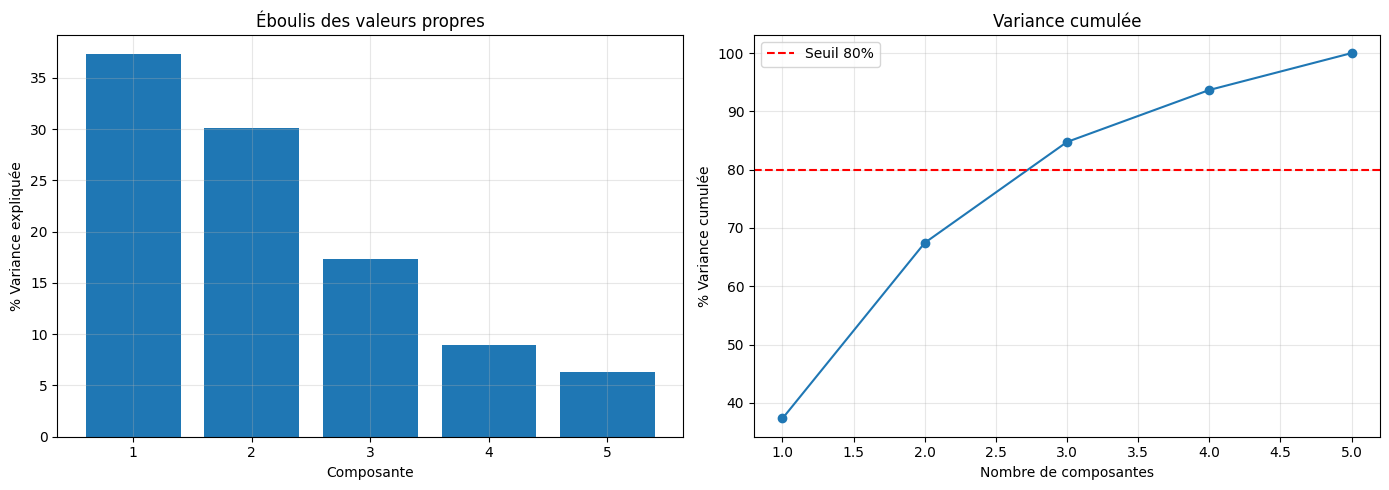


Variance expliquée par composante :
F1 : 37.32%
F2 : 30.13%
F3 : 17.31%
F4 : 8.91%
F5 : 6.33%

Variance cumulée F1+F2 : 67.45%


In [30]:
# ACP
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# VISUALISATION 1 : Éboulis des valeurs propres
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Variance expliquée
axes[0].bar(range(1, len(pca.explained_variance_ratio_)+1), 
            pca.explained_variance_ratio_ * 100)
axes[0].set_xlabel('Composante')
axes[0].set_ylabel('% Variance expliquée')
axes[0].set_title('Éboulis des valeurs propres')
axes[0].grid(alpha=0.3)

# Variance cumulée
axes[1].plot(range(1, len(pca.explained_variance_ratio_)+1),
             np.cumsum(pca.explained_variance_ratio_) * 100, 
             marker='o')
axes[1].axhline(80, color='red', linestyle='--', label='Seuil 80%')
axes[1].set_xlabel('Nombre de composantes')
axes[1].set_ylabel('% Variance cumulée')
axes[1].set_title('Variance cumulée')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nVariance expliquée par composante :")
for i, var in enumerate(pca.explained_variance_ratio_[:5], 1):
    print(f"F{i} : {var*100:.2f}%")
print(f"\nVariance cumulée F1+F2 : {sum(pca.explained_variance_ratio_[:2])*100:.2f}%")

### Cercle corrélations

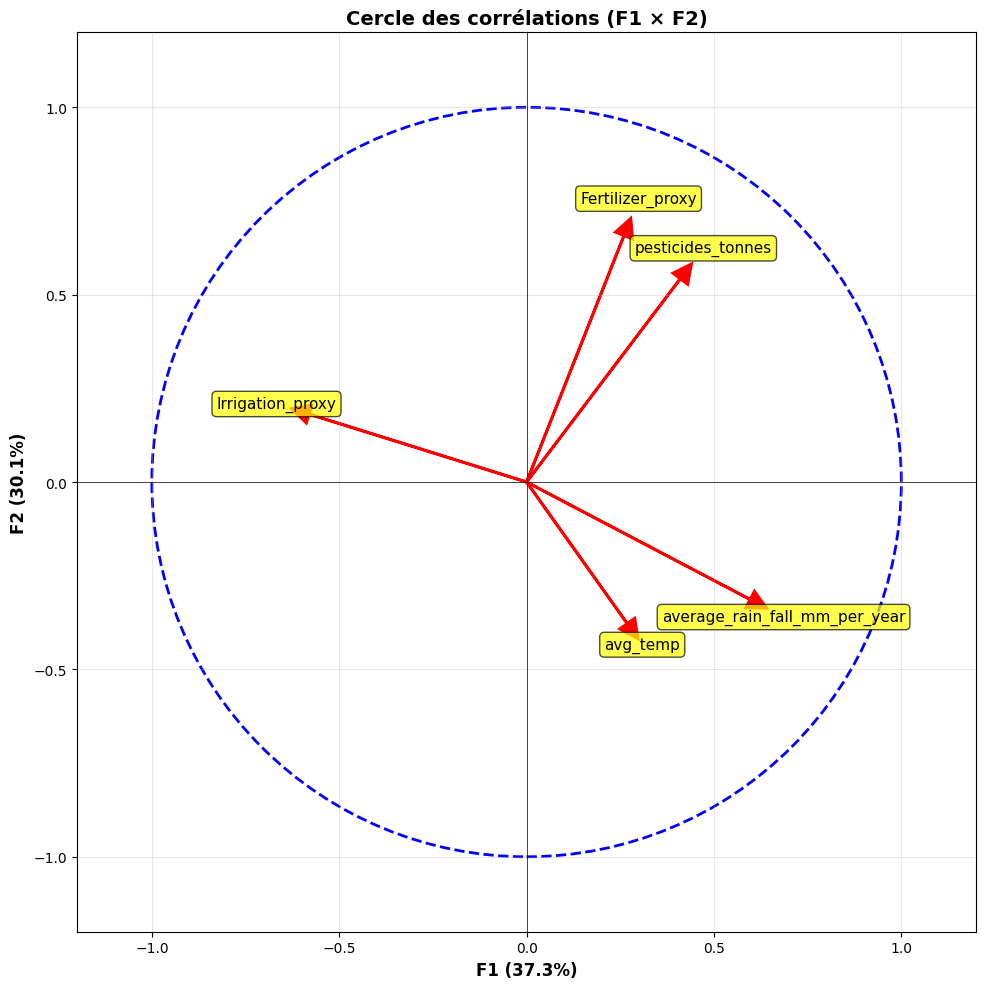


=== CONTRIBUTIONS DES VARIABLES AUX COMPOSANTES ===

                                  F1     F2     F3
average_rain_fall_mm_per_year  0.596 -0.313 -0.138
pesticides_tonnes              0.410  0.542  0.173
avg_temp                       0.268 -0.378  0.853
Fertilizer_proxy               0.260  0.658  0.158
Irrigation_proxy              -0.580  0.181  0.446


In [31]:
# VISUALISATION 2 : Cercle des corrélations

# Composantes principales (corrélations variables/composantes)
components = pca.components_[:2]  # F1 et F2

fig, ax = plt.subplots(figsize=(10, 10))

# Cercle unité
circle = plt.Circle((0, 0), 1, color='blue', fill=False, linestyle='--', linewidth=2)
ax.add_patch(circle)

# Axes
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)

# Flèches des variables
for i, var in enumerate(features_acp):
    x = components[0, i]
    y = components[1, i]
    ax.arrow(0, 0, x, y, head_width=0.05, head_length=0.05, 
             fc='red', ec='red', linewidth=2)
    # Labels décalés
    ax.text(x*1.15, y*1.15, var, fontsize=11, ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

# Paramètres
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_xlabel(f'F1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12, fontweight='bold')
ax.set_ylabel(f'F2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12, fontweight='bold')
ax.set_title('Cercle des corrélations (F1 × F2)', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

# Matrice des contributions
print("\n=== CONTRIBUTIONS DES VARIABLES AUX COMPOSANTES ===\n")
contributions = pd.DataFrame(
    pca.components_[:3].T,
    columns=['F1', 'F2', 'F3'],
    index=features_acp
)
print(contributions.round(3))

## ACP par types de cultures
**Objectif :** Analyser si la structure varie selon les cultures et identifier les spécificités de chacune.

**Contexte :** L'ACP globale (section précédente) a révélé une variance modérée (F1+F2=67.45%) avec des dimensions "Disponibilité en eau" (F1) et "Intensité agricole" (F2). Cette analyse par culture permettra de vérifier si ces dimensions sont universelles ou si chaque culture présente des patterns spécifiques.

**Méthodologie :** Nous appliquerons la même ACP (5 features : Rainfall, Pesticides, Temperature, Fertilizer_proxy, Irrigation_proxy) séparément sur les 5 cultures principales du dataset. Pour chaque culture, nous générerons l'éboulis des valeurs propres et le cercle des corrélations.

**Critère décision :** Si les structures factorielles divergent significativement entre cultures (ex: F1 Rice ≠ F1 Maize), cela justifiera une modélisation séparée par culture plutôt qu'un modèle global.

### Sélection des cultures à analyser

In [32]:
# Sélection des 5 cultures principales (représentativité + lisibilité)
top_5_cultures = df_final_2['Item'].value_counts().head(5).index.tolist()
print(f"Cultures analysées : {top_5_cultures}\n")

# Stockage résultats
resultats_acp = {}

for culture in top_5_cultures:
    # Filtrer + calculer ACP
    df_cult = df_final_2[df_final_2['Item'] == culture].copy()
    X = df_cult[features_acp].dropna()
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    pca = PCA()
    pca.fit(X_scaled)
    
    resultats_acp[culture] = {
        'pca': pca,
        'n_obs': len(X)
    }
    print(f"{culture:20s} | N={len(X):4d} | F1={pca.explained_variance_ratio_[0]*100:5.2f}% | F2={pca.explained_variance_ratio_[1]*100:5.2f}% | F1+F2={sum(pca.explained_variance_ratio_[:2])*100:5.2f}%")


Cultures analysées : ['Potatoes', 'Maize', 'Wheat', 'Rice, paddy', 'Soybeans']

Potatoes             | N=4276 | F1=37.19% | F2=28.84% | F1+F2=66.03%
Maize                | N=4121 | F1=37.18% | F2=30.91% | F1+F2=68.10%
Wheat                | N=3857 | F1=41.54% | F2=23.52% | F1+F2=65.06%
Rice, paddy          | N=3388 | F1=36.89% | F2=31.81% | F1+F2=68.70%
Soybeans             | N=3223 | F1=38.02% | F2=30.19% | F1+F2=68.22%


Les 5 cultures principales (Potatoes, Maize, Wheat, Rice, Soybeans) représentent 18,865 lignes sur 28,242 (67% du dataset), garantissant une représentativité statistique robuste pour l'analyse comparative. Les variances cumulées F1+F2 sont remarquablement homogènes (65-69%), suggérant une structure factorielle stable entre cultures. Wheat se distingue par une F1 plus élevée (41.5%) et F2 plus faible (23.5%), indiquant une répartition différente de la variance entre dimensions.

### ACP, éboulis et Cercles de corrélations par culture (5 cultures)

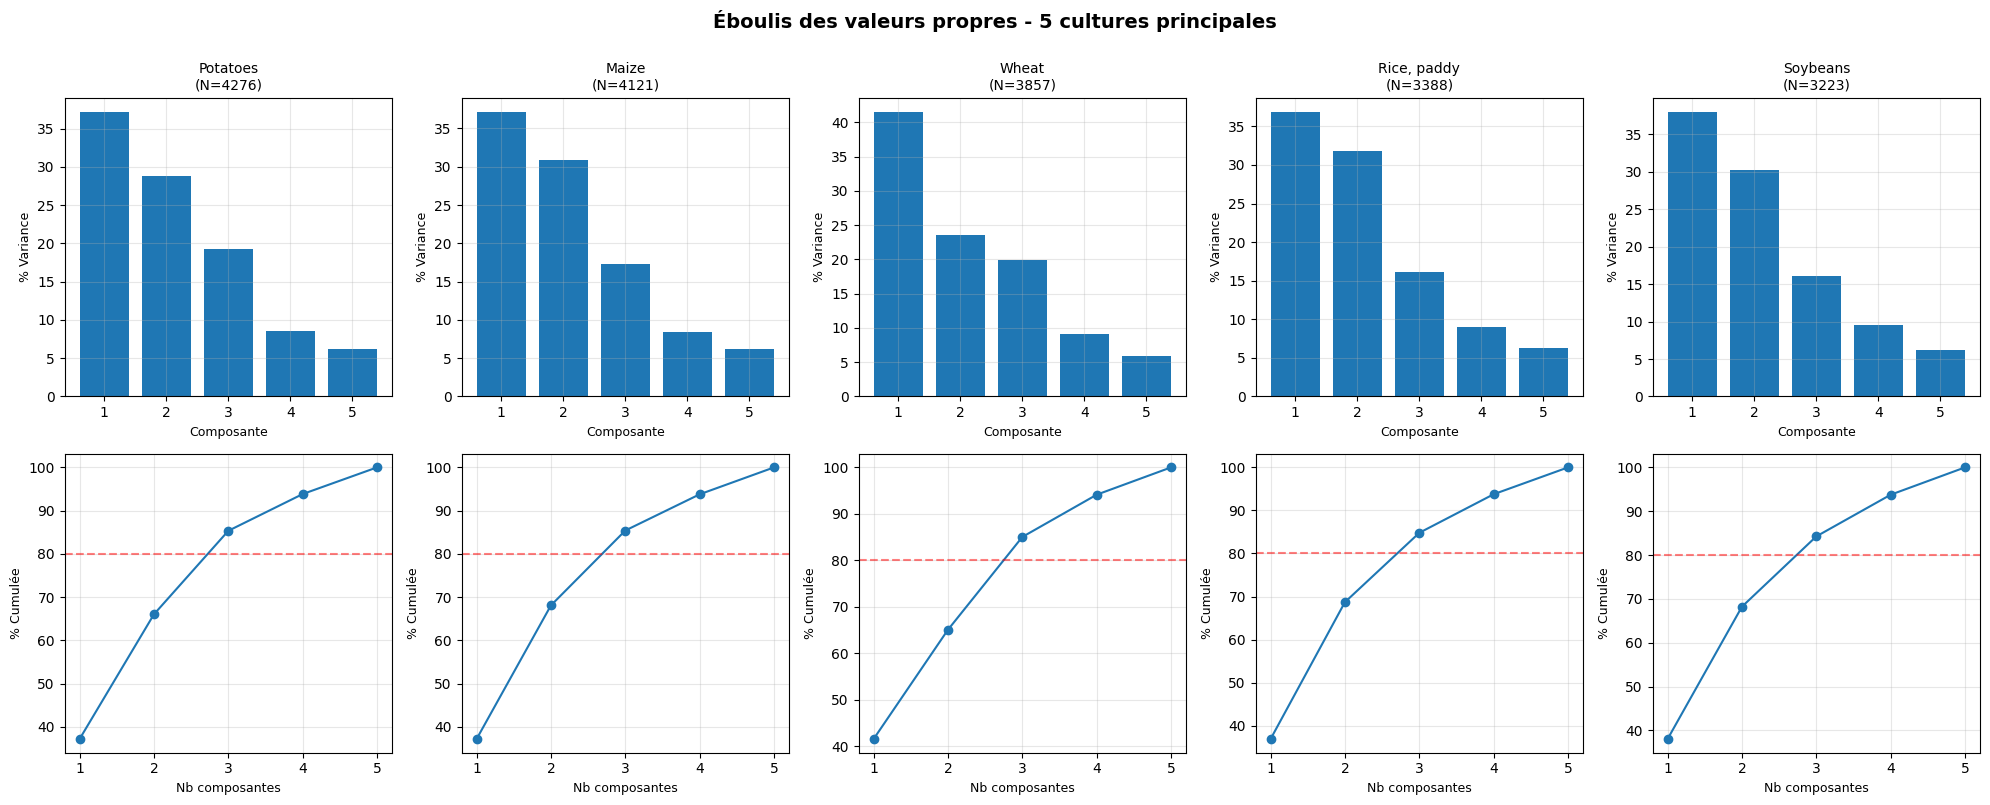

In [33]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for idx, culture in enumerate(top_5_cultures):
    pca = resultats_acp[culture]['pca']
    
    # Éboulis
    axes[0, idx].bar(range(1, 6), pca.explained_variance_ratio_ * 100)
    axes[0, idx].set_title(f'{culture}\n(N={resultats_acp[culture]["n_obs"]})', fontsize=10)
    axes[0, idx].set_xlabel('Composante', fontsize=9)
    axes[0, idx].set_ylabel('% Variance', fontsize=9)
    axes[0, idx].grid(alpha=0.3)
    
    # Variance cumulée
    axes[1, idx].plot(range(1, 6), np.cumsum(pca.explained_variance_ratio_[:5]) * 100, marker='o')
    axes[1, idx].axhline(80, color='red', linestyle='--', alpha=0.5)
    axes[1, idx].set_xlabel('Nb composantes', fontsize=9)
    axes[1, idx].set_ylabel('% Cumulée', fontsize=9)
    axes[1, idx].grid(alpha=0.3)

plt.suptitle('Éboulis des valeurs propres - 5 cultures principales', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()


Les éboulis révèlent une décroissance progressive similaire pour toutes cultures, avec F1 dominant (36-41%) et nécessitant 3 composantes pour atteindre le seuil de 80% de variance expliquée. Les courbes de variance cumulée présentent des trajectoires quasi-parallèles, confirmant l'homogénéité structurelle malgré les différences agronomiques entre tubercules (Potatoes), céréales tempérées (Wheat) et tropicales (Rice, Maize). Cette stabilité valide l'approche d'un modèle ML global plutôt que des modèles séparés par culture.

### Cercles corrélations (5 cultures)

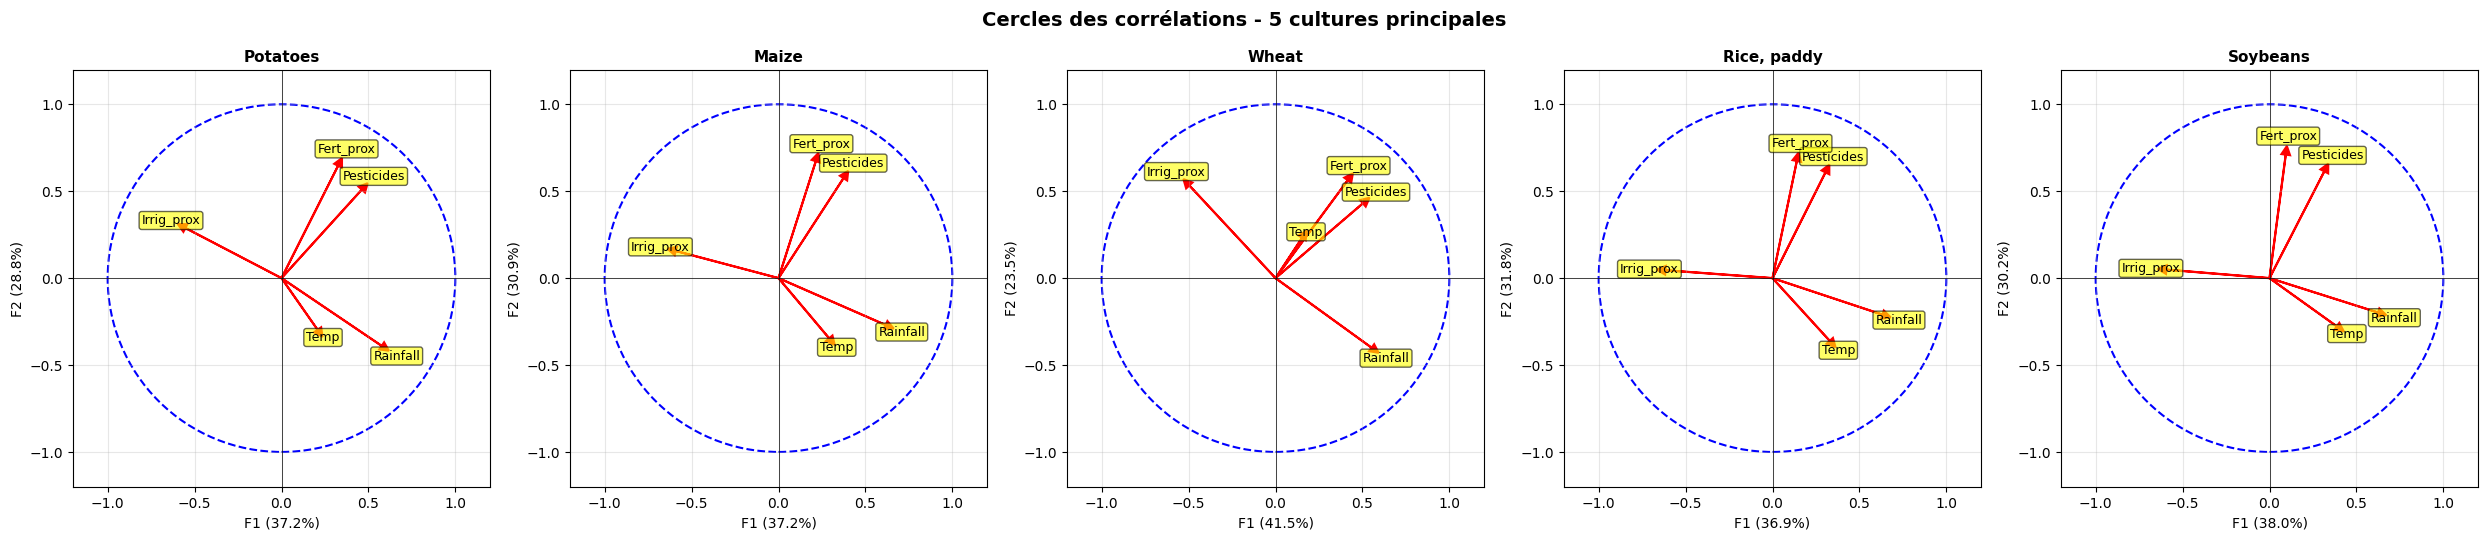

In [34]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for idx, culture in enumerate(top_5_cultures):
    pca = resultats_acp[culture]['pca']
    components = pca.components_[:2]
    
    ax = axes[idx]
    
    # Cercle
    circle = plt.Circle((0, 0), 1, color='blue', fill=False, linestyle='--', linewidth=1.5)
    ax.add_patch(circle)
    
    # Axes
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)
    
    # Flèches
    for i, var in enumerate(features_acp):
        x = components[0, i]
        y = components[1, i]
        ax.arrow(0, 0, x, y, head_width=0.05, head_length=0.05, fc='red', ec='red', linewidth=1.5)
        
        # Labels simplifiés
        var_short = var.replace('average_rain_fall_mm_per_year', 'Rainfall')\
                       .replace('pesticides_tonnes', 'Pesticides')\
                       .replace('Fertilizer_proxy', 'Fert_prox')\
                       .replace('Irrigation_proxy', 'Irrig_prox')\
                       .replace('avg_temp', 'Temp')
        
        ax.text(x*1.15, y*1.15, var_short, fontsize=9, ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='yellow', alpha=0.6))
    
    # Paramètres
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.set_xlabel(f'F1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=10)
    ax.set_ylabel(f'F2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=10)
    ax.set_title(culture, fontsize=11, fontweight='bold')
    ax.grid(alpha=0.3)
    ax.set_aspect('equal')

plt.suptitle('Cercles des corrélations - 5 cultures principales', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Les cercles révèlent une configuration quasi-identique pour Potatoes, Maize, Rice et Soybeans avec F1 opposant Rainfall (Sud-Est) à Irrigation_proxy (Ouest) et F2 regroupant Fertilizer_proxy et Pesticides (Nord). Wheat présente une divergence notable avec Temperature recentrée (contribution F1/F2 réduite) et Irrigation_proxy montant sur F2, reflétant la moindre thermosensibilité de cette culture tempérée. Les dimensions "Disponibilité en eau" (F1) et "Intensité agricole" (F2) restent universelles pour 4 cultures sur 5, justifiant un modèle global avec vigilance sur l'interprétation Wheat.

### Conclusions

L'ACP par culture confirme une structure factorielle largement homogène (variance F1+F2 = 65-69%) avec des dimensions "Eau" et "Intensité agricole" universelles pour 80% des cultures analysées. La spécificité de Wheat (réorganisation axes eau/température) reste minoritaire et ne justifie pas une modélisation séparée, d'autant que les 4 autres cultures majeures (67% des données) présentent des patterns identiques. Décision : Modèle ML global avec features [Temperature, Rainfall, Fertilizer_proxy, Irrigation_proxy, Item_encoded] pertinent pour l'ensemble du dataset.

## Analyse temporelle
On va vérifier si les rendements évoluent significativement sur la période d'observation (1990 -> 2013). Les résultats nous permettront de prendre en compte l'évolution des rendements dans le modèle de façon à ne pas sous-estimer les prédictions 2026
- Ne pas sous-estimer les prédictions et recommandations qui se feront pour 2026

Ces rendements seront analysés par type de culture avec régression linéaire pour quantifier la pente d'évolution.

### Représentations graphiques des évolutions

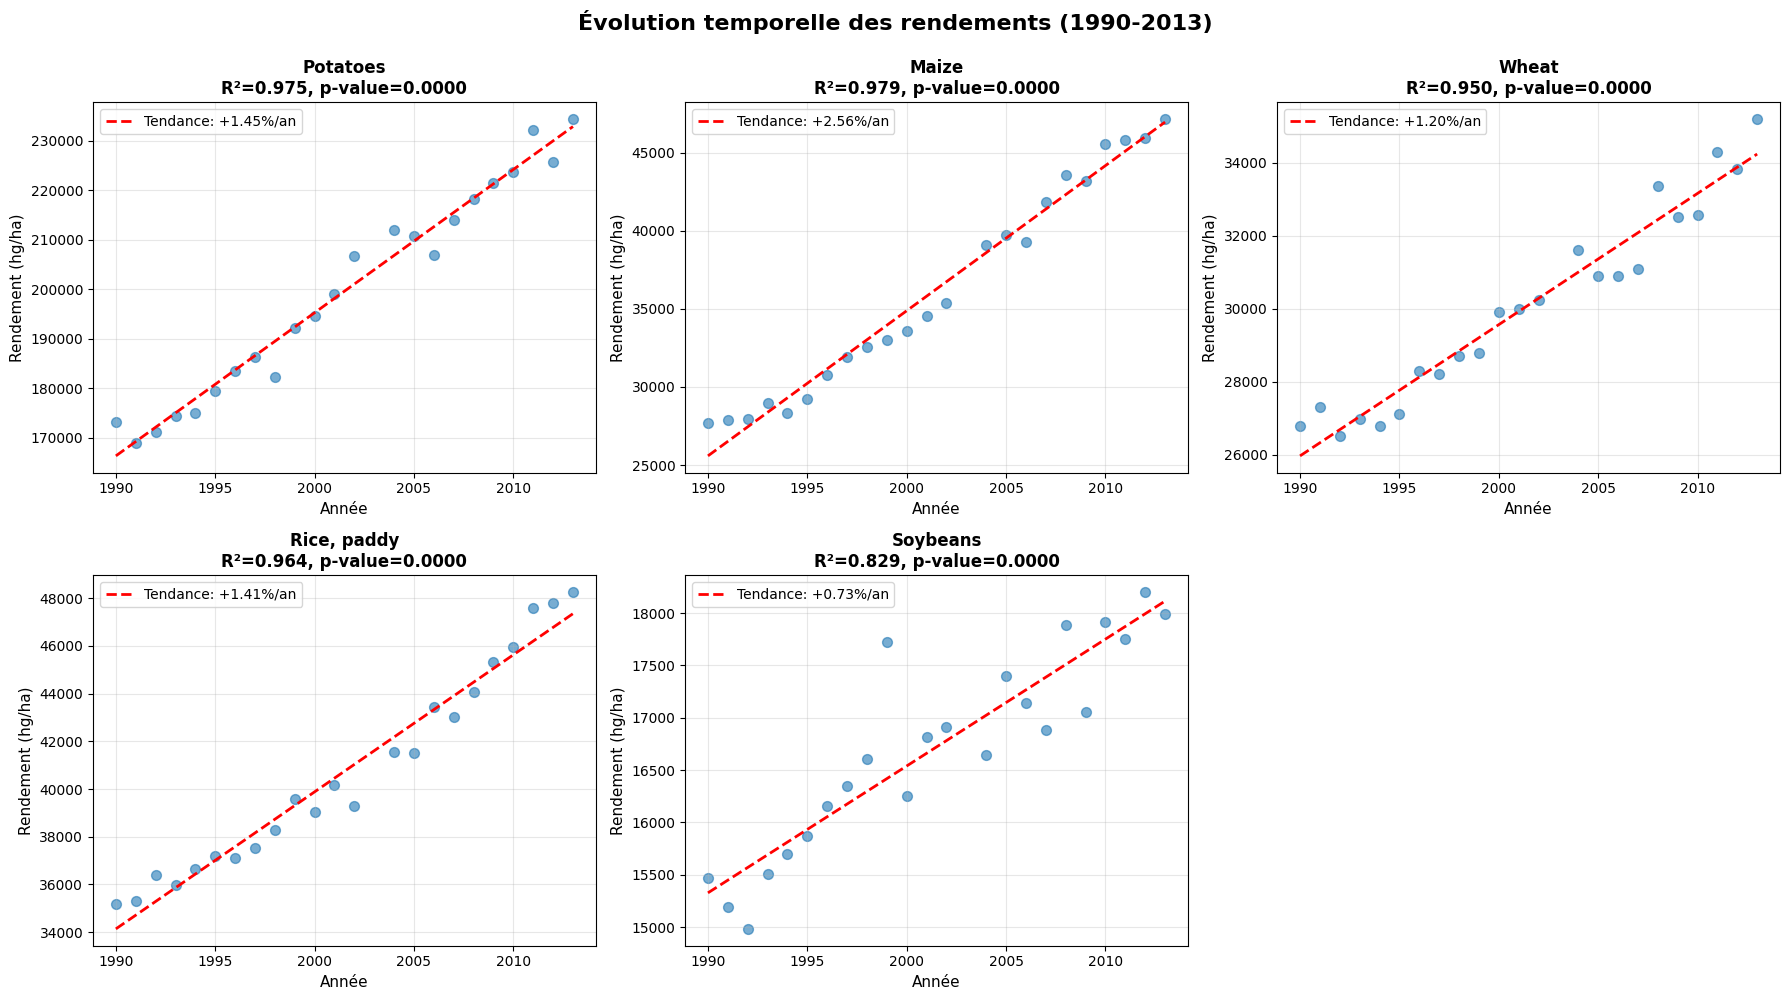


=== SYNTHÈSE TENDANCES TEMPORELLES ===

Culture              |  Évolution %/an |       R² |    p-value |             Décision
-------------------------------------------------------------------------------------
Potatoes             |          +1.45% |    0.975 |     0.0000 |       ✅ Inclure Year
Maize                |          +2.56% |    0.979 |     0.0000 |       ✅ Inclure Year
Wheat                |          +1.20% |    0.950 |     0.0000 |       ✅ Inclure Year
Rice, paddy          |          +1.41% |    0.964 |     0.0000 |       ✅ Inclure Year
Soybeans             |          +0.73% |    0.829 |     0.0000 |       ✅ Inclure Year



In [35]:
# Cultures à analyser
cultures_temporel = ['Potatoes', 'Maize', 'Wheat', 'Rice, paddy', 'Soybeans']

# Calcul rendements moyens par année et culture
rendements_annuels = df_final_2.groupby(['Year', 'Item'])['yield_hg_per_ha'].mean().reset_index()

# Stockage résultats
resultats_temporel = {}

# Graphique
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, culture in enumerate(cultures_temporel):
    # Filtrer culture
    df_cult = rendements_annuels[rendements_annuels['Item'] == culture]
    
    # Régression linéaire
    slope, intercept, r_value, p_value, std_err = stats.linregress(df_cult['Year'], df_cult['yield_hg_per_ha'])
    
    # Calcul évolution %/an (sur moyenne période)
    rendement_moyen = df_cult['yield_hg_per_ha'].mean()
    evolution_pct_an = (slope / rendement_moyen) * 100
    
    # Stockage
    resultats_temporel[culture] = {
        'slope': slope,
        'r2': r_value**2,
        'p_value': p_value,
        'evolution_pct_an': evolution_pct_an
    }
    
    # Graphique
    ax = axes[idx]
    ax.scatter(df_cult['Year'], df_cult['yield_hg_per_ha'], alpha=0.6, s=50)
    ax.plot(df_cult['Year'], intercept + slope * df_cult['Year'], 
            'r--', linewidth=2, label=f'Tendance: {evolution_pct_an:+.2f}%/an')
    
    ax.set_xlabel('Année', fontsize=11)
    ax.set_ylabel('Rendement (hg/ha)', fontsize=11)
    ax.set_title(f'{culture}\nR²={r_value**2:.3f}, p-value={p_value:.4f}', 
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

# Masquer dernier subplot
axes[-1].axis('off')

plt.suptitle('Évolution temporelle des rendements (1990-2013)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Tableau synthèse
print("\n=== SYNTHÈSE TENDANCES TEMPORELLES ===\n")
print(f"{'Culture':<20} | {'Évolution %/an':>15} | {'R²':>8} | {'p-value':>10} | {'Décision':>20}")
print("-" * 85)

for culture, res in resultats_temporel.items():
    if res['evolution_pct_an'] > 0.5:
        decision = "✅ Inclure Year"
    elif res['evolution_pct_an'] < 0.2:
        decision = "❌ Ignorer temporel"
    else:
        decision = "⚠️ Tendance modérée"
    
    print(f"{culture:<20} | {res['evolution_pct_an']:>+14.2f}% | {res['r2']:>8.3f} | {res['p_value']:>10.4f} | {decision:>20}")

print("\n" + "="*85)

### Analyse des tendances observées

Les tendances observées (+0.73% à +2.56%/an, R²>0.95, p<0.001) sont cohérentes avec les données FAO qui rapportent des croissances de rendements de 19% à 33% entre 2000-2020 pour les principales céréales (maïs, riz, blé). Cette continuité des gains de productivité agricole sur plusieurs décennies, portée par l'amélioration des variétés et des pratiques culturales, justifie l'inclusion de la variable `Year` dans le modèle prédictif pour capturer cette composante temporelle.

**Source :** FAO (2022). FAOSTAT Analytical Brief 41: Agricultural production statistics 2000-2020.  
https://openknowledge.fao.org/server/api/core/bitstreams/b75223dd-4e30-43aa-85a9-4c587753b027/content

### Autres observations selon les données FAO

L'analyse du rapport FAO révèle des hétérogénéités géographiques majeures :

**Rendements absolus :** Pour le maïs en 2020, les rendements moyens varient de ~2 t/ha en Afrique à ~8 t/ha en Amériques/Océanie, soit un facteur ×4 entre régions pour une même culture.

**Vitesse d'évolution :** Entre 2000-2020, les rendements du maïs ont progressé de +56% en Asie contre seulement +16% en Afrique, révélant des dynamiques régionales divergentes.

Ces disparités suggèrent que la composante temporelle (progrès agricoles) n'impacte pas uniformément toutes les zones géographiques.

### Décisions modélisation

**✅ Variable Year incluse** : Feature directe pour capturer tendance temporelle globale.

**✅ Clustering géographique** : Segmentation des pays en clusters homogènes basée sur caractéristiques climatiques (température, pluviométrie) et niveau d'intensification agricole (pesticides comme proxy développement technologique). Objectif : améliorer prédictions vs modèle global unique. Analyse dans section suivante.

**⚠️ Interaction Year×Cluster** : Envisagée si clustering révèle groupes avec dynamiques temporelles distinctes (ex: "croissance rapide Asie" vs "stagnation Afrique"). À tester selon résultats clustering.

### Limites et hypothèses

**Hypothèse extrapolation 2013-2026 :** L'inclusion de Year suppose poursuite linéaire des tendances observées sur 13 années supplémentaires (2013→2026). Cette hypothèse comporte des incertitudes :

- **Ralentissement documenté :** La littérature FAO rapporte un ralentissement de la croissance des rendements depuis les années 1990 (loi des rendements décroissants), suggérant que les taux observés 1990-2013 pourraient ne pas se maintenir.

- **Plafonds agronomiques :** Les rendements approchent progressivement de limites biologiques et physiques dans certaines régions.

- **Changement climatique :** Stress hydriques et thermiques croissants non capturés par tendance historique.

**Conséquence :** Les prédictions 2026 doivent être interprétées comme estimations hautes, avec intervalle de confiance élargi pour refléter cette incertitude structurelle.

## Clustering géographique

### Agrégation des données par pays

#### Agrégation

On ne va agréger que les valeurs liées aux variables climat (avg_temp et average_rain_fall_mm_per_year) des pays. 
L'usage de pesticides en valeurs absolues (tonnes) reflète à la fois l'intensité agricole ET la taille du pays. Idéalement, un ratio tonnes/surface agricole mesurerait mieux l'intensification. En l'absence de données de surface dans les datasets FAO utilisés (yield.csv, pesticides.csv, rainfall.csv, temp.csv), nous écartons cette variable.

In [36]:
# Calculer moyennes par pays (toutes années et cultures confondues)
df_pays = df_final_2.groupby('Area').agg({
    'avg_temp': 'mean',
    'average_rain_fall_mm_per_year': 'mean',
    'Area_Code': 'first'  # Garder le code pays pour fusion ultérieure
}).reset_index()

# Renommer colonnes pour clarté
df_pays.columns = ['Area', 'Temp_moyenne', 'Rainfall_moyenne', 'Area_Code']

# Afficher résultat
print(f"Nombre de pays : {len(df_pays)}")
print(f"\nAperçu données agrégées :\n")
print(df_pays.head(10))
print(f"\nStatistiques descriptives :\n")
print(df_pays[['Temp_moyenne', 'Rainfall_moyenne']].describe())

Nombre de pays : 101

Aperçu données agrégées :

         Area  Temp_moyenne  Rainfall_moyenne  Area_Code
0     Albania     16.300101            1485.0          3
1     Algeria     17.484825              89.0          4
2      Angola     24.311341            1010.0          7
3   Argentina     17.530870             591.0          9
4     Armenia      9.580952             562.0          1
5   Australia     16.712174             534.0         10
6     Austria      9.121979            1110.0         11
7  Azerbaijan     12.439828             447.0         52
8     Bahamas     25.463582            1292.0         12
9     Bahrain     26.703448              83.0         13

Statistiques descriptives :

       Temp_moyenne  Rainfall_moyenne
count    101.000000        101.000000
mean      18.426781       1062.613861
std        7.364579        727.679050
min        3.459565         51.000000
25%       11.016923        589.000000
50%       19.686957        847.000000
75%       25.463582       15

#### Détermination du nombre optimal de clusters

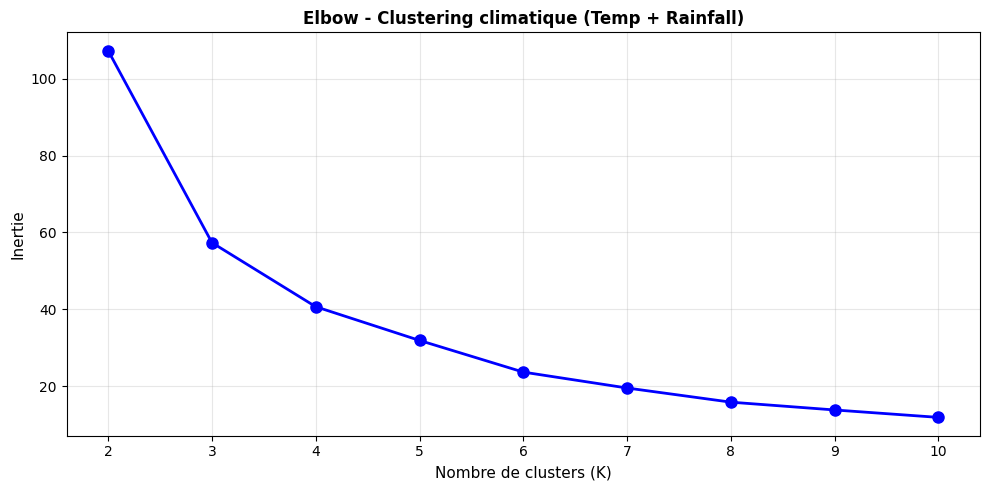

Inertie par K (climat seul) :
  K=2 : 107.28
  K=3 : 57.33
  K=4 : 40.67
  K=5 : 31.90
  K=6 : 23.66
  K=7 : 19.53
  K=8 : 15.84
  K=9 : 13.82
  K=10 : 11.89


In [37]:
# Features climatiques uniquement
features_climat = ['Temp_moyenne', 'Rainfall_moyenne']
X_climat = df_pays[features_climat].values

# Standardisation
scaler_climat = StandardScaler()
X_climat_scaled = scaler_climat.fit_transform(X_climat)

# Elbow method
inertias_climat = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans.fit(X_climat_scaled)
    inertias_climat.append(kmeans.inertia_)

# Visualisation
plt.figure(figsize=(10, 5))
plt.plot(K_range, inertias_climat, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Nombre de clusters (K)', fontsize=11)
plt.ylabel('Inertie', fontsize=11)
plt.title('Elbow - Clustering climatique (Temp + Rainfall)', fontsize=12, fontweight='bold')
plt.grid(alpha=0.3)
plt.xticks(K_range)
plt.tight_layout()
plt.show()

print("Inertie par K (climat seul) :")
for k, inertia in zip(K_range, inertias_climat):
    print(f"  K={k} : {inertia:.2f}")

#### Application K-means (K=4)

In [38]:
# Entraîner modèle
kmeans_climat = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10)
clusters_climat = kmeans_climat.fit_predict(X_climat_scaled)

# Assigner clusters
df_pays['Cluster_climat'] = clusters_climat

print("=== CLUSTERING CLIMATIQUE (K=4) ===\n")
print("Répartition pays par cluster :")
print(df_pays['Cluster_climat'].value_counts().sort_index())

print("\nCaractéristiques moyennes par cluster :")
cluster_climat_stats = df_pays.groupby('Cluster_climat')[['Temp_moyenne', 'Rainfall_moyenne']].mean()
print(cluster_climat_stats.round(1))

=== CLUSTERING CLIMATIQUE (K=4) ===

Répartition pays par cluster :
Cluster_climat
0    28
1    32
2    12
3    29
Name: count, dtype: int64

Caractéristiques moyennes par cluster :
                Temp_moyenne  Rainfall_moyenne
Cluster_climat                                
0                       22.4            1444.3
1                        9.2             785.6
2                       25.9            2497.1
3                       21.7             406.2


#### Visualisation et renommage des clusters climatiques

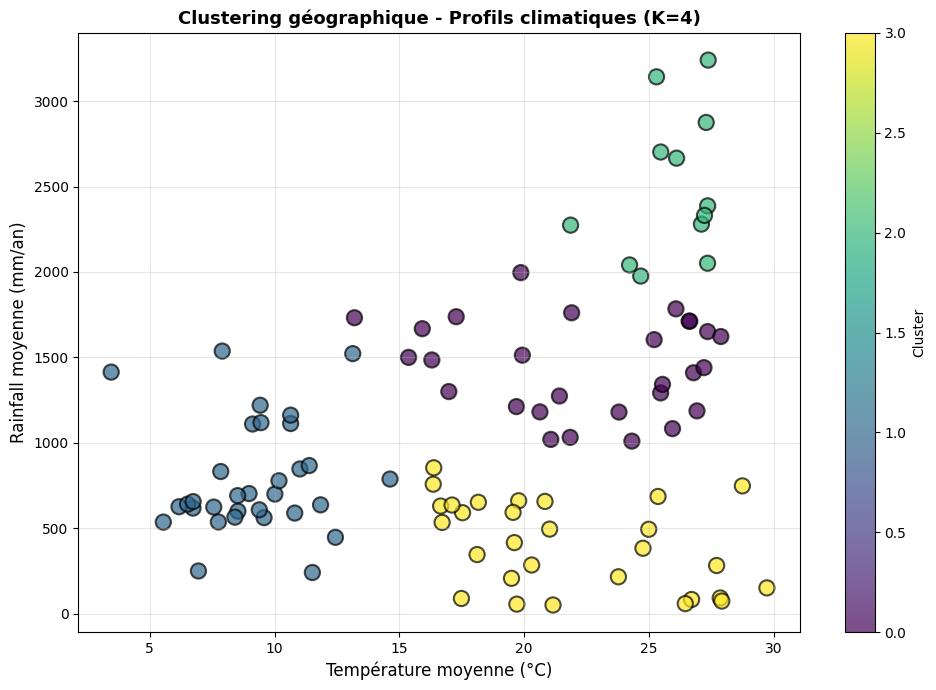

In [39]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(df_pays['Temp_moyenne'], 
                      df_pays['Rainfall_moyenne'],
                      c=df_pays['Cluster_climat'], 
                      cmap='viridis', s=120, alpha=0.7, edgecolors='black', linewidth=1.5)

plt.xlabel('Température moyenne (°C)', fontsize=12)
plt.ylabel('Rainfall moyenne (mm/an)', fontsize=12)
plt.title('Clustering géographique - Profils climatiques (K=4)', fontsize=13, fontweight='bold')
plt.colorbar(scatter, label='Cluster')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [40]:
### Pays par cluster climatique

for cluster in range(4):
    pays_cluster = df_pays[df_pays['Cluster_climat'] == cluster]['Area'].sort_values().tolist()
    print(f"\n=== CLUSTER {cluster} ({len(pays_cluster)} pays) ===")
    print(", ".join(pays_cluster))


=== CLUSTER 0 (28 pays) ===
Albania, Angola, Bahamas, Brazil, Burundi, Cameroon, Central African Republic, Dominican Republic, El Salvador, Ghana, Guatemala, Guinea, Haiti, India, Japan, Madagascar, Malawi, Mozambique, Nepal, New Zealand, Peru, Rwanda, Sri Lanka, Sudan, Thailand, Uganda, Uruguay, Zambia

=== CLUSTER 1 (32 pays) ===
Armenia, Austria, Azerbaijan, Belarus, Belgium, Bulgaria, Canada, Chile, Croatia, Denmark, Estonia, Finland, France, Germany, Hungary, Ireland, Italy, Kazakhstan, Latvia, Lesotho, Lithuania, Montenegro, Netherlands, Norway, Poland, Romania, Slovenia, Sweden, Switzerland, Tajikistan, Ukraine, United Kingdom

=== CLUSTER 2 (12 pays) ===
Bangladesh, Colombia, Ecuador, Guyana, Honduras, Indonesia, Jamaica, Malaysia, Mauritius, Nicaragua, Papua New Guinea, Suriname

=== CLUSTER 3 (29 pays) ===
Algeria, Argentina, Australia, Bahrain, Botswana, Burkina Faso, Egypt, Eritrea, Greece, Iraq, Kenya, Lebanon, Libya, Mali, Mauritania, Mexico, Morocco, Namibia, Niger, Pak

In [41]:
### Renommage clusters avec labels climatiques

# Mapping clusters → labels
cluster_labels = {
    0: 'Tempéré',
    1: 'Tempéré_humide', 
    2: 'Semi_aride',
    3: 'Tropical_humide'
}

df_pays['Cluster_label'] = df_pays['Cluster_climat'].map(cluster_labels)

print("=== CLUSTERS RENOMMÉS ===\n")
print(df_pays.groupby('Cluster_label').size())

=== CLUSTERS RENOMMÉS ===

Cluster_label
Semi_aride         12
Tempéré            28
Tempéré_humide     32
Tropical_humide    29
dtype: int64


## Fusion finale et sauvegarde

In [42]:
# Fusionner clusters avec df_final_2 (28,242 lignes)
df_final_enrichi = df_final_2.merge(
    df_pays[['Area_Code', 'Cluster_climat', 'Cluster_label']], 
    on='Area_Code', 
    how='left'
)

print("=== DATASET FINAL ENRICHI ===")
print(f"Shape : {df_final_enrichi.shape}")
print(f"\nRépartition clusters (28k lignes) :")
print(df_final_enrichi['Cluster_label'].value_counts())

# Sauvegarde
output_path = DONNEES_PROCESSED / "dataset_modelisation_v1.csv"
df_final_enrichi.to_csv(output_path, index=False)
print(f"\n✅ Dataset V1 sauvegardé : {output_path}")

=== DATASET FINAL ENRICHI ===
Shape : (28242, 13)

Répartition clusters (28k lignes) :
Cluster_label
Tempéré            11547
Tropical_humide     9412
Tempéré_humide      3961
Semi_aride          3322
Name: count, dtype: int64

✅ Dataset V1 sauvegardé : C:\Users\Fab\Documents\P12_systeme_reco_agriculture\data\processed\dataset_modelisation_v1.csv


In [43]:
df_final_enrichi.head()

,Area,Area_Code,Item,Year,yield_hg_per_ha,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp_old,avg_temp,Fertilizer_proxy,Irrigation_proxy,Cluster_climat,Cluster_label
0,Albania,3,Maize,1990,36613,1485.0,121.0,16.37,16.37,0,0,0,Tempéré
1,Albania,3,Potatoes,1990,66667,1485.0,121.0,16.37,16.37,0,0,0,Tempéré
2,Albania,3,"Rice, paddy",1990,23333,1485.0,121.0,16.37,16.37,0,0,0,Tempéré
3,Albania,3,Sorghum,1990,12500,1485.0,121.0,16.37,16.37,0,0,0,Tempéré
4,Albania,3,Soybeans,1990,7000,1485.0,121.0,16.37,16.37,0,0,0,Tempéré
